In [9]:

import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler
import tensorly as tl
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from utils import (
    COLS, COL_IDX, load_case,
    hosvd, run_pod, reconstruct_hosvd, reconstruct_pod,
    minmax, minmax_scale_point, standardise_train,
    rel_error,
    make_mo_gpr,
plot_singular_values, plot_hosvd_coeffs, plot_pod_coeffs,
    plot_error_bars, plot_field,
)

# ─────────────────────────────────────────────────────────────────────────────
# configuration
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR  = Path('/home/isacco/DATA/')
CASES_DIR = DATA_DIR / 'Datasets_Isacco'
PLOT_DIR  = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

RE_VALS = [11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000]
MF_VALS = [0.04,  0.06,  0.08,  0.10,  0.12,  0.14,  0.16,  0.18,  0.20,  0.22]

RE_TRAIN_VALS = [11000, 12000, 13000, 14000, 16000, 17000, 18000, 19000, 20000]
MF_TRAIN_VALS = [0.04,  0.06,  0.08, 0.12,  0.14,  0.16,  0.18,  0.20,  0.22]

RE_TEST_VALS = [15000]
MF_TEST      = 0.10
MF_TEST_VALS = MF_VALS

IMPORTANT_FIELDS = [ 'T',

    # Main species
    'CH4', 'O2', 'CO', 'CO2', 'H2O',
]
KERNEL_1D  = ConstantKernel(1.0) * Matern(length_scale=0.5,
                                            length_scale_bounds='fixed', nu=0.5)
KERNEL_2D  = ConstantKernel(1.0) * Matern(length_scale=np.full(2, 0.5),
                                            length_scale_bounds='fixed', nu=0.5)
E_THRESHOLD = 0.99


# ─────────────────────────────────────────────────────────────────────────────
# 1. load all 100 cases
# ─────────────────────────────────────────────────────────────────────────────

print('Loading cases...')
sample_grid, x_vals, z_vals = load_case(sorted(CASES_DIR.glob('*.xy'))[0])
Nz, Nx, Nsp  = sample_grid.shape
x_min, x_max = x_vals.min(), x_vals.max()
z_min, z_max = z_vals.min(), z_vals.max()

params_all      = np.array([[re, mf] for re in RE_VALS for mf in MF_VALS])
tensor_flat_all = np.empty((len(params_all), Nz, Nx, Nsp), dtype=np.float32)
for k, (re, mf) in enumerate(params_all):
    path = next(CASES_DIR.glob(f'*_mfH2_{mf:.2f}_Re_{int(re)}.xy'))
    tensor_flat_all[k], _, _ = load_case(path)

print(f'Full tensor shape: {tensor_flat_all.shape}')


# ─────────────────────────────────────────────────────────────────────────────
# 2. train / test split
# ─────────────────────────────────────────────────────────────────────────────

mf_train_set = {round(v, 2) for v in MF_TRAIN_VALS}

def in_train(re, mf):
    return (re in RE_TRAIN_VALS) and (round(mf, 2) in mf_train_set)

def get_test_field(re_test, mf_test):
    mask = np.array([(re == re_test) and (round(mf, 2) == round(mf_test, 2))
                     for re, mf in params_all])
    return tensor_flat_all[mask][0]

train_mask   = np.array([in_train(re, mf) for re, mf in params_all])
params_train = params_all[train_mask]
T_train      = tensor_flat_all[train_mask]

print(f'Training cases : {len(params_train)}  '
      f'(Re={RE_TRAIN_VALS}, mf={MF_TRAIN_VALS})')


# ─────────────────────────────────────────────────────────────────────────────
# 3. standardise
# ─────────────────────────────────────────────────────────────────────────────

T_train_s, mu, std = standardise_train(T_train)


# ─────────────────────────────────────────────────────────────────────────────
# 4. HOSVD
# ─────────────────────────────────────────────────────────────────────────────

n_re_tr      = len(RE_TRAIN_VALS)
n_mf_tr      = len(MF_TRAIN_VALS)
re_to_idx_tr = {v: i for i, v in enumerate(RE_TRAIN_VALS)}
mf_to_idx_tr = {round(v, 2): j for j, v in enumerate(MF_TRAIN_VALS)}

T_grid = np.zeros((n_re_tr, n_mf_tr, Nz, Nx, Nsp), dtype=np.float32)
for k, (re, mf) in enumerate(params_train):
    i = re_to_idx_tr[int(re)]
    j = mf_to_idx_tr[round(mf, 2)]
    T_grid[i, j] = T_train[k]

T_grid_s = (T_grid - mu) / std
print(f'\nHOSVD grid tensor shape: {T_grid_s.shape}')

print('Running HOSVD...')
core, factors, sv_list = hosvd(T_grid_s, energy_threshold=E_THRESHOLD)
U_re, U_mf = factors[0], factors[1]
r_re, r_mf = U_re.shape[1], U_mf.shape[1]
print(f'U_re: {U_re.shape}   U_mf: {U_mf.shape}   core: {core.shape}')


# ─────────────────────────────────────────────────────────────────────────────
# 5. POD
# ─────────────────────────────────────────────────────────────────────────────

print('\nRunning POD...')
V_pod, S_pod, a_tr = run_pod(T_train_s, energy_threshold=E_THRESHOLD)
r_pod = V_pod.shape[1]
print(f'POD rank: {r_pod}')

Loading cases...
Full tensor shape: (100, 201, 79, 29)
Training cases : 81  (Re=[11000, 12000, 13000, 14000, 16000, 17000, 18000, 19000, 20000], mf=[0.04, 0.06, 0.08, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22])

HOSVD grid tensor shape: (9, 9, 201, 79, 29)
Running HOSVD...


HOSVD modes: 100%|██████████| 5/5 [00:15<00:00,  3.17s/it]


U_re: (9, 9)   U_mf: (9, 9)   core: (9, 9, 201, 79, 29)

Running POD...
POD rank: 76


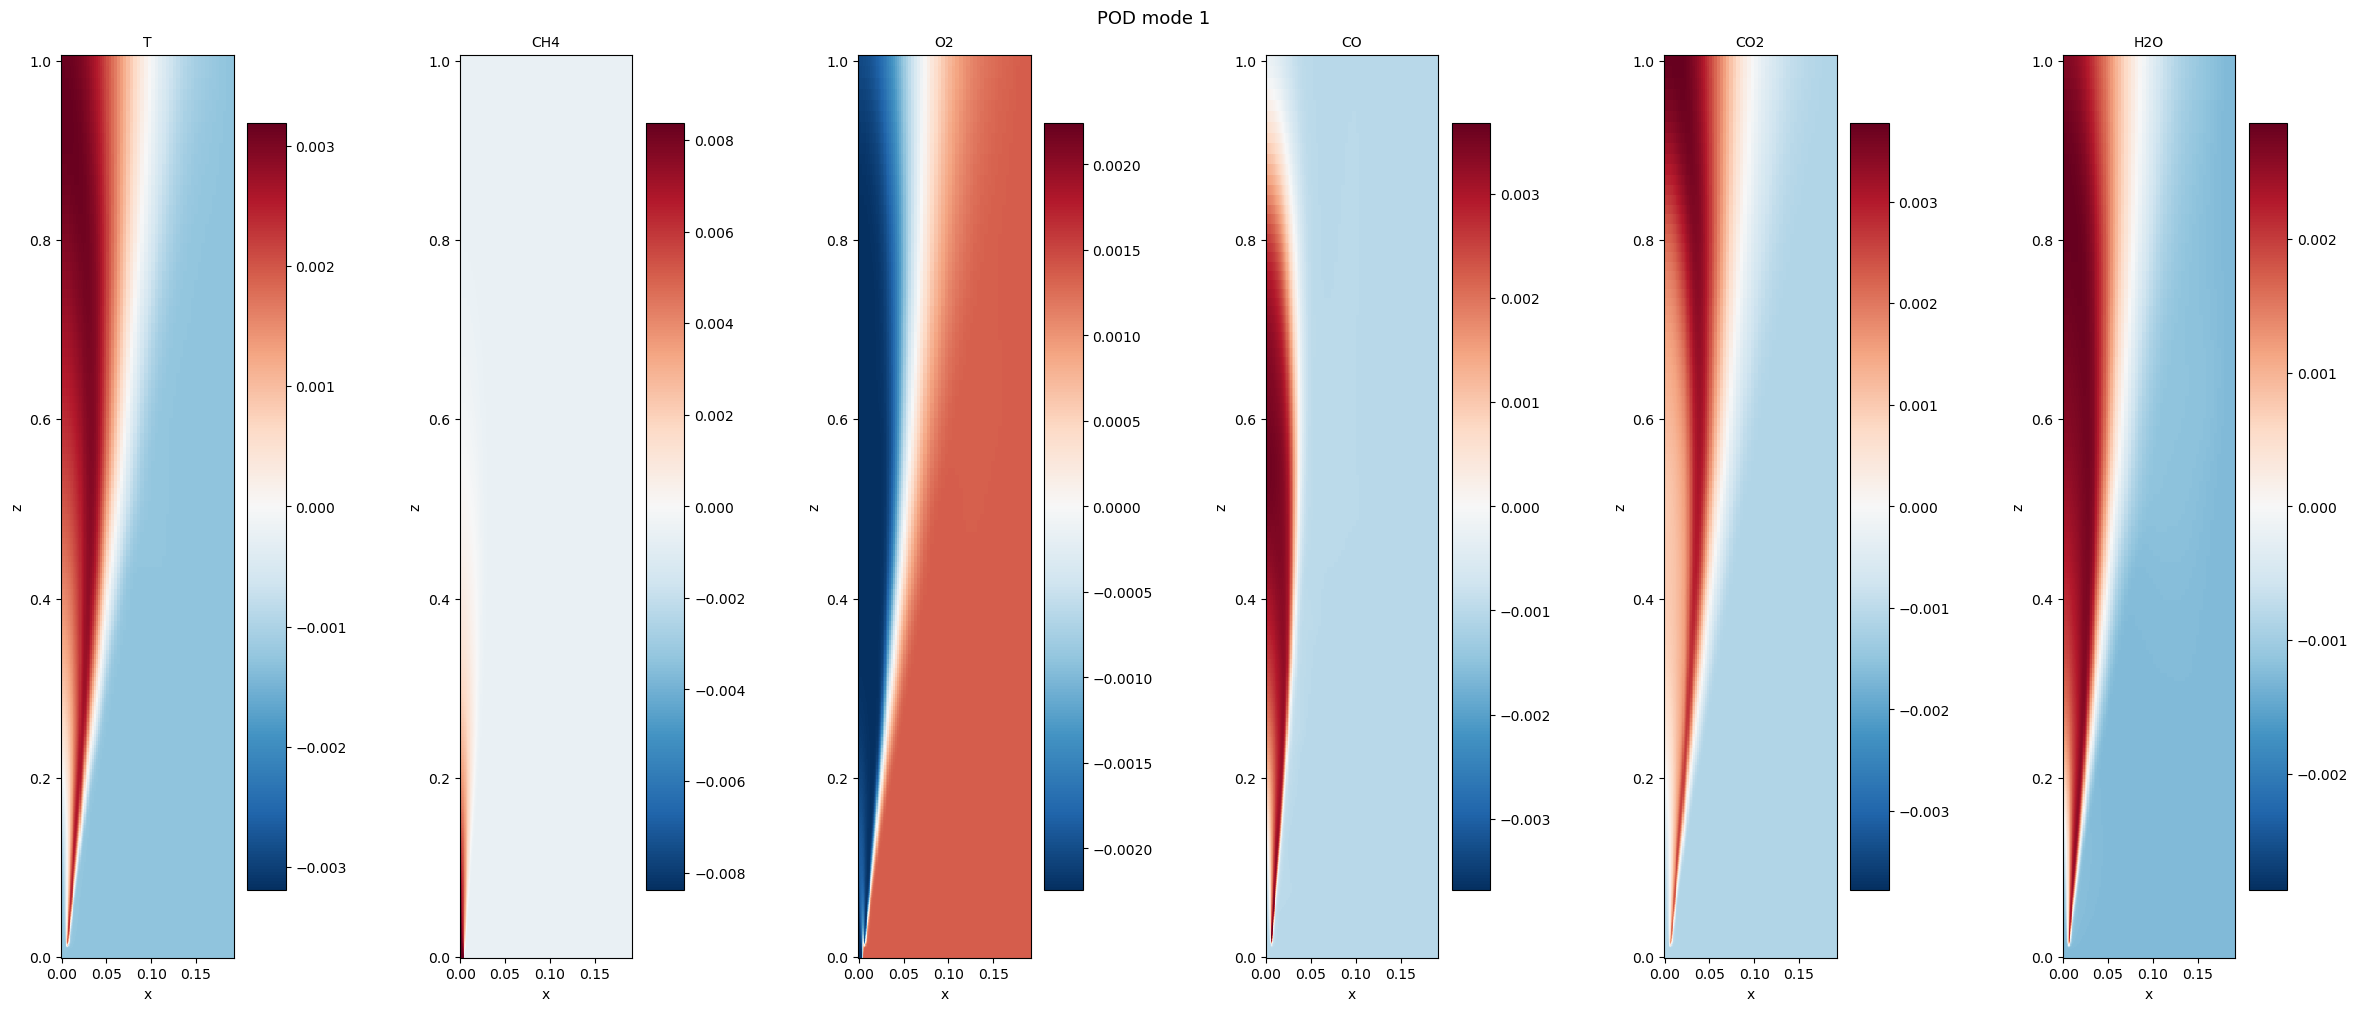

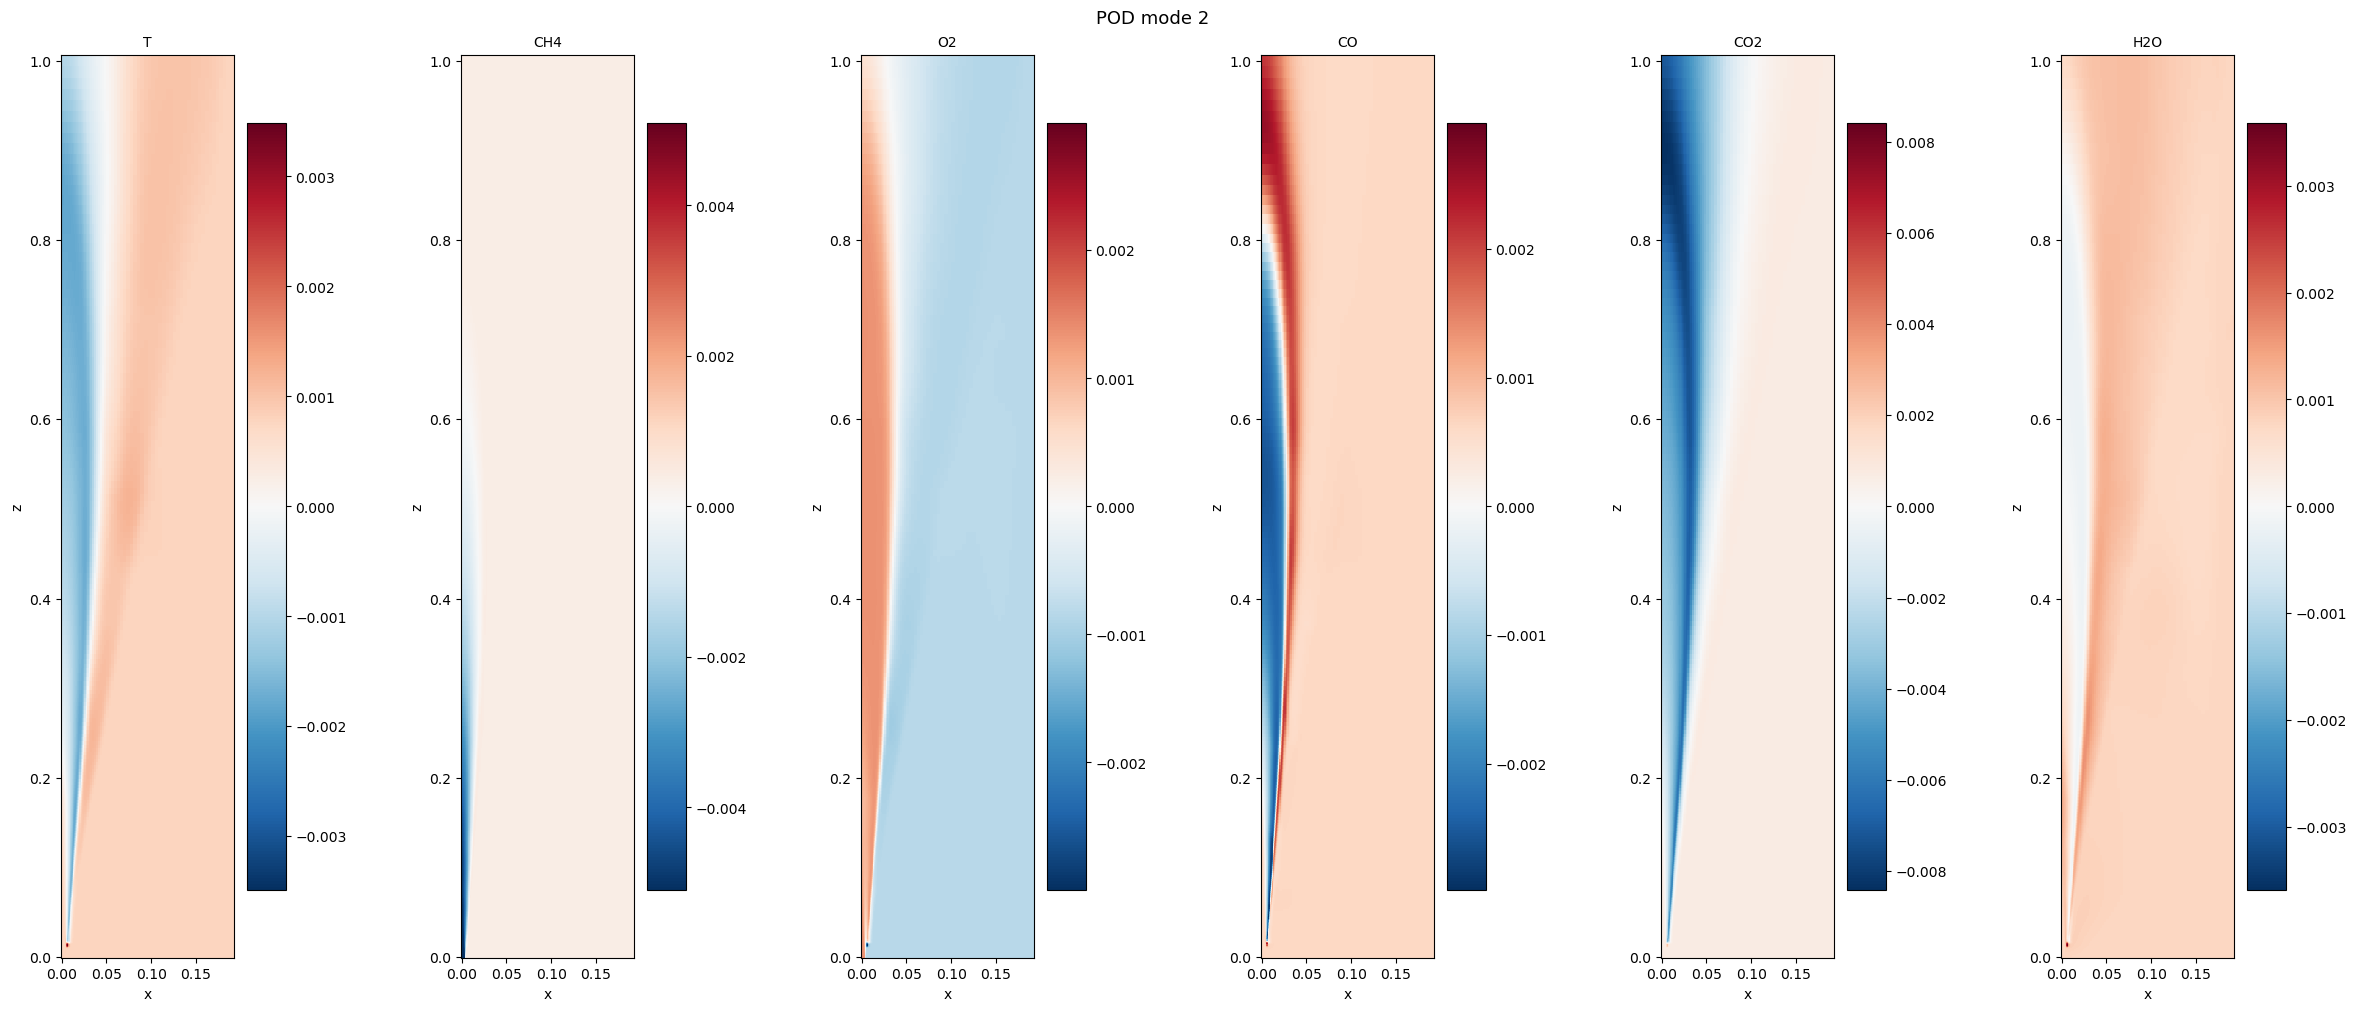

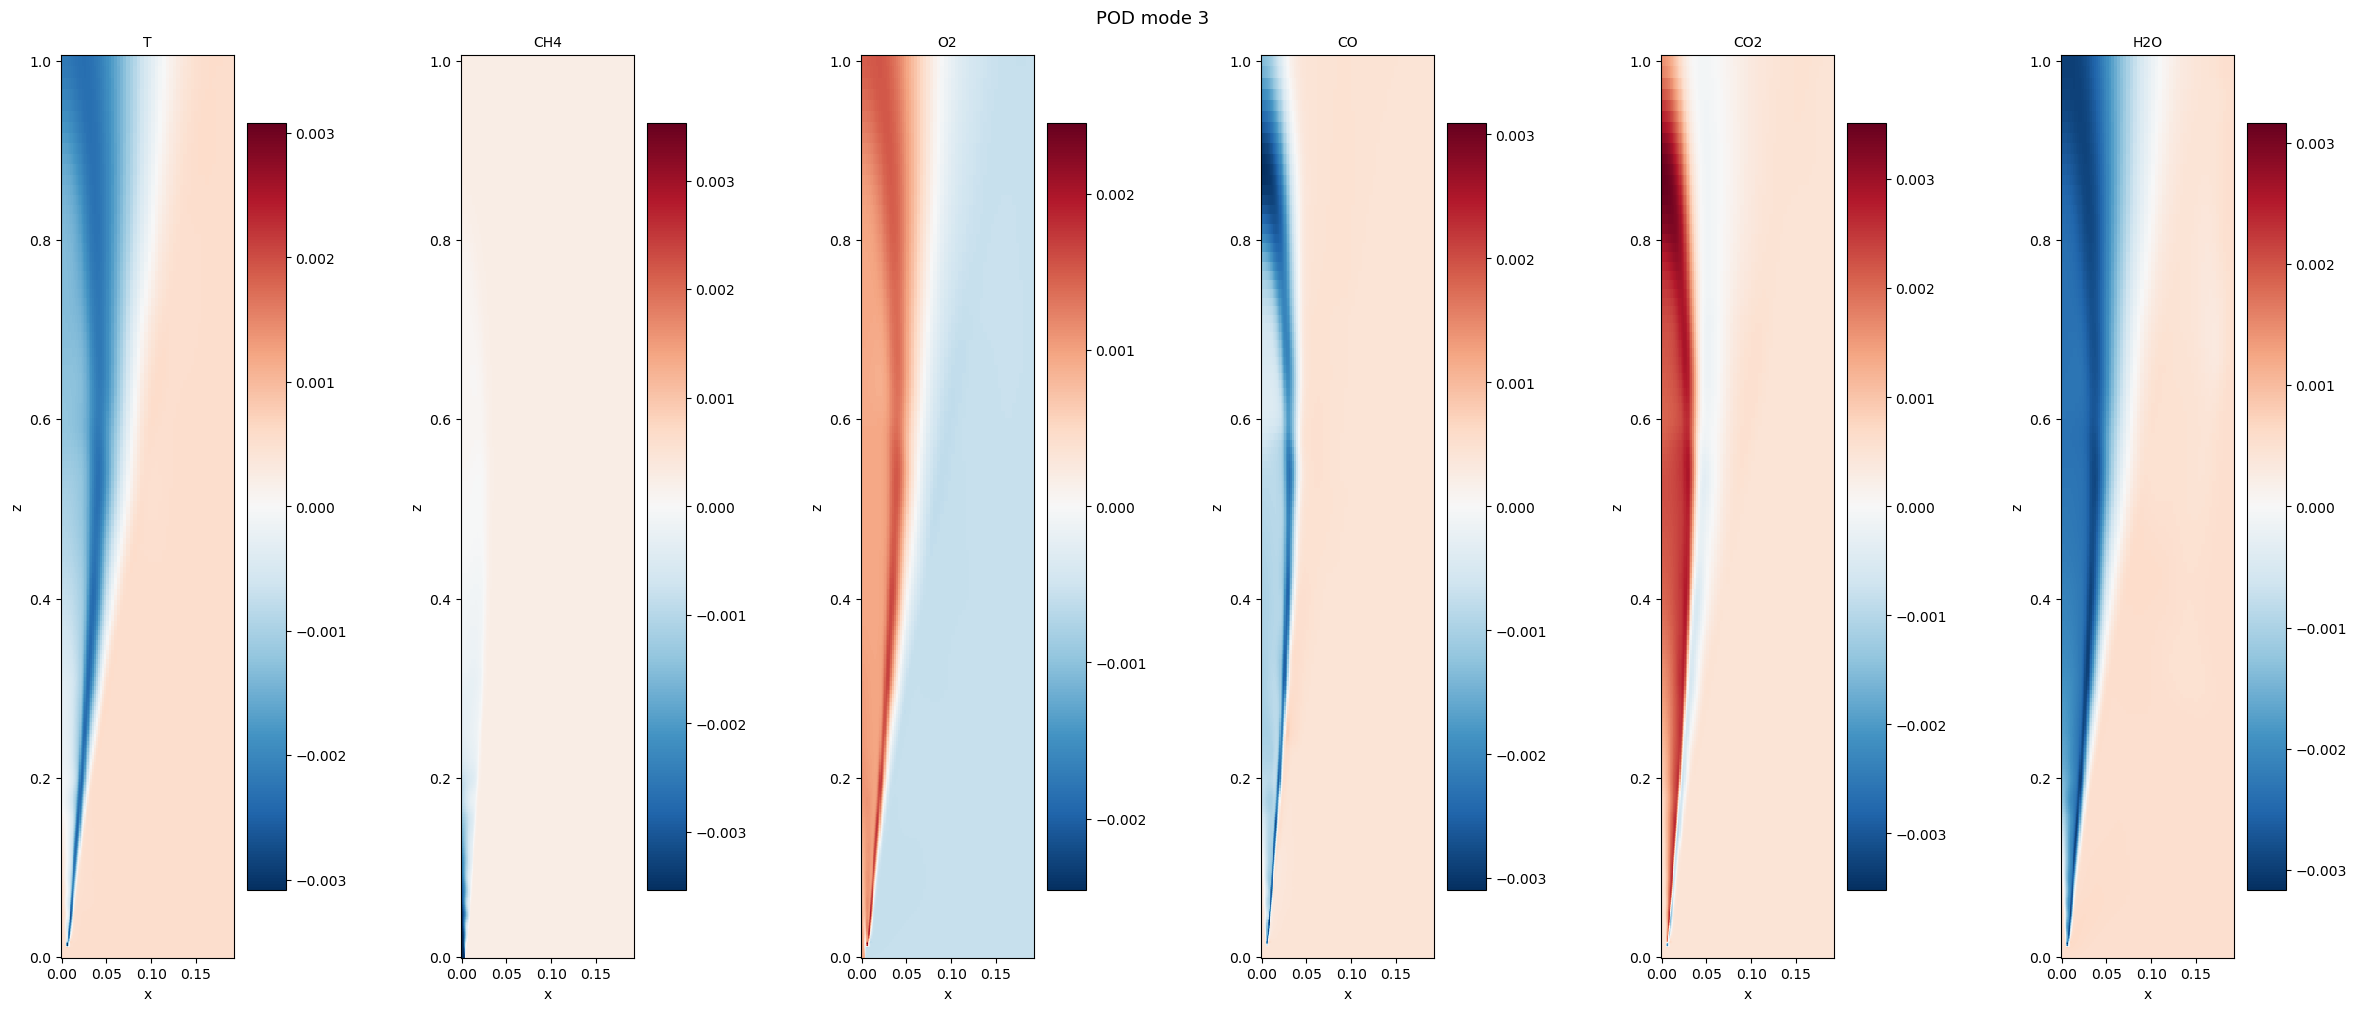

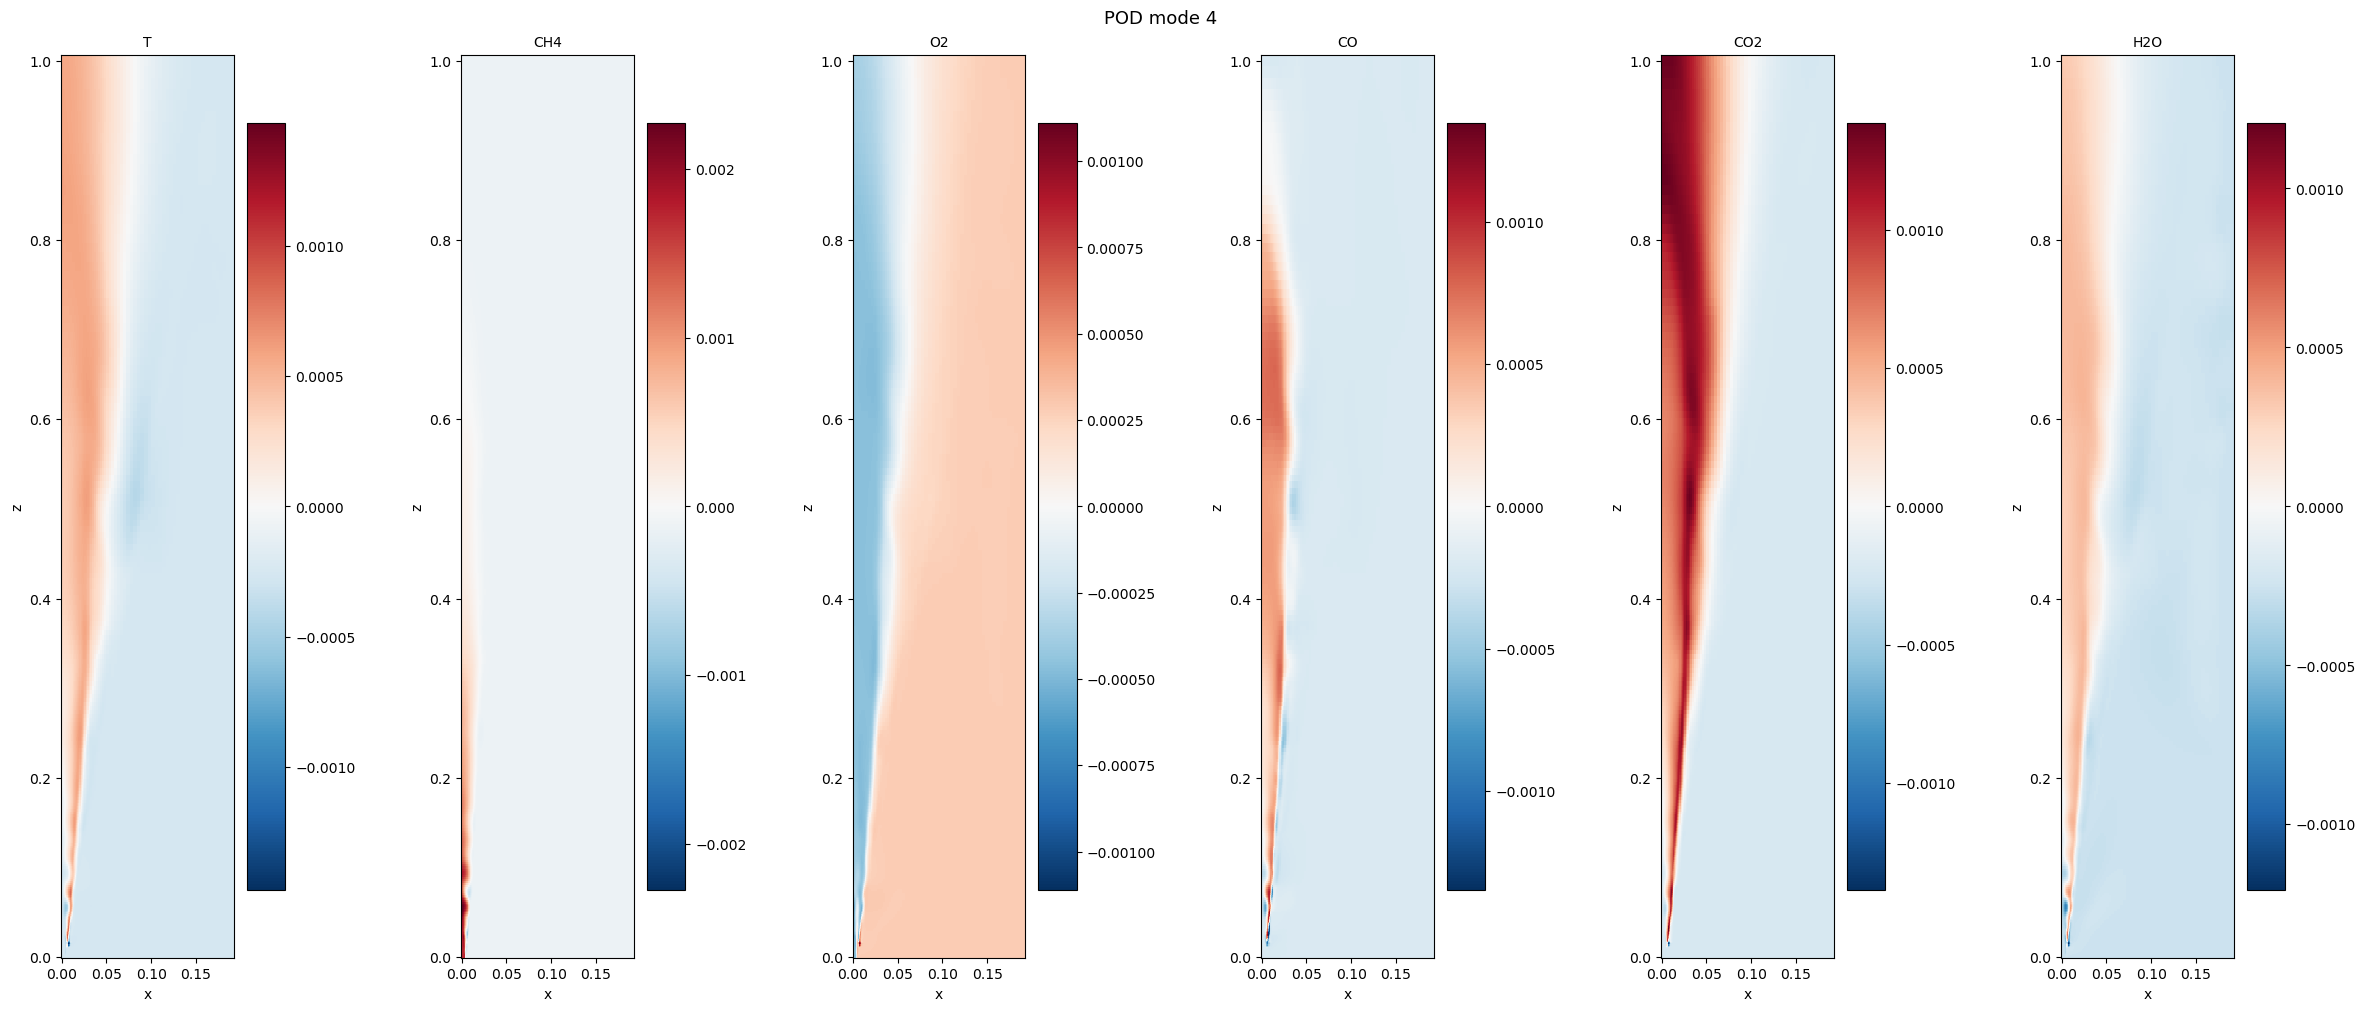

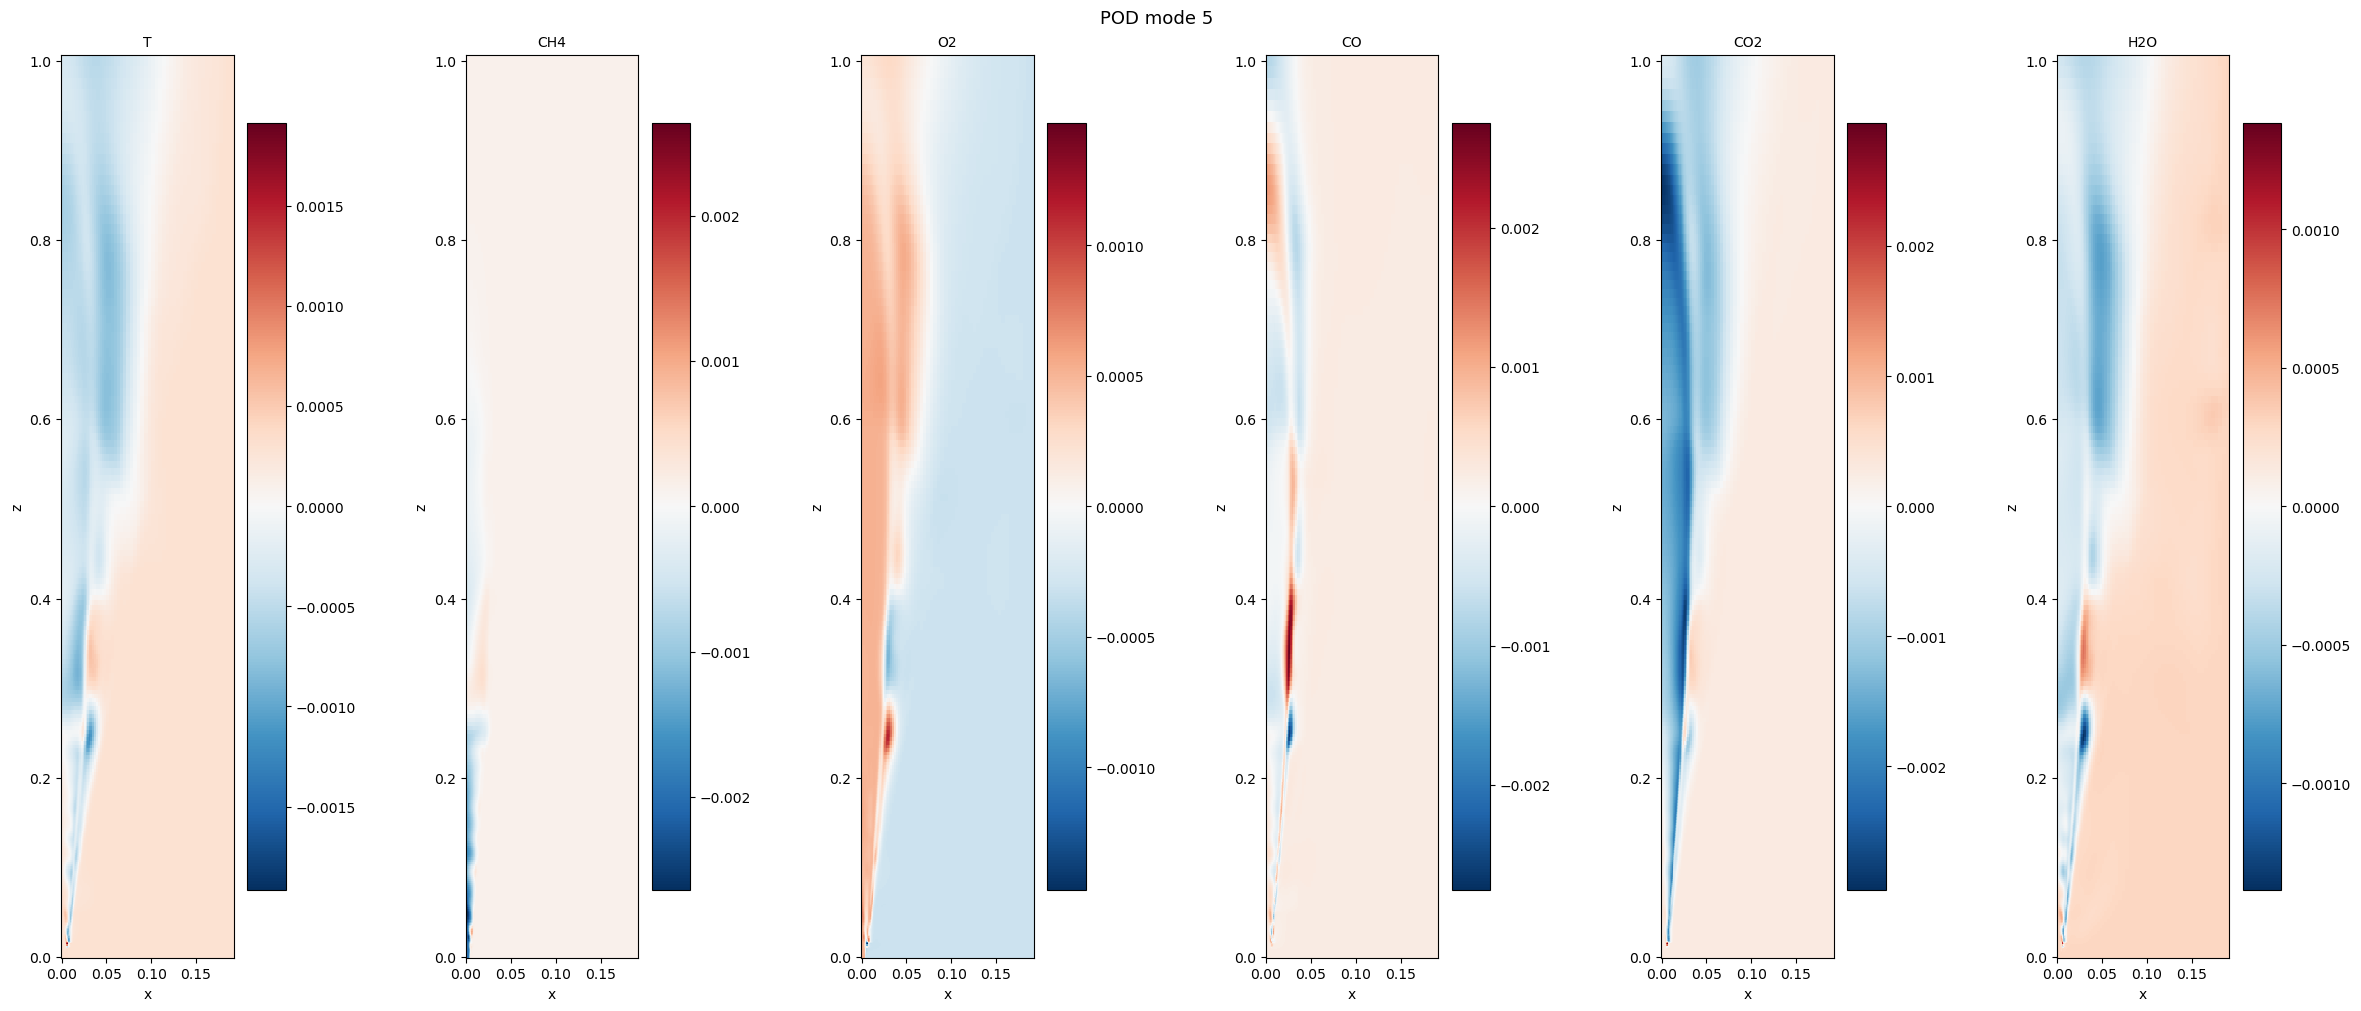

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualise POD modes  (spatial structure per field)
# ─────────────────────────────────────────────────────────────────────────────

V_4d = V_pod.reshape(Nz, Nx, Nsp, r_pod)   # (Nz, Nx, Nsp, r_pod)

fields_to_plot = IMPORTANT_FIELDS           # change subset here if needed
n_fields = len(fields_to_plot)

for mode_idx in range(5):
    fig, axes = plt.subplots(
        1, n_fields,
        figsize=(4 * n_fields, 10),
        constrained_layout=True,
    )
    if n_fields == 1:
        axes = [axes]

    fig.suptitle(f'POD mode {mode_idx + 1}', fontsize=13)

    for ax, field in zip(axes, fields_to_plot):
        sp_idx = COL_IDX[field]                        # species/field index
        mode_2d = V_4d[:, :, sp_idx, mode_idx]        # (Nz, Nx)

        vmax = np.abs(mode_2d).max()
        im = ax.pcolormesh(
            x_vals, z_vals, mode_2d,
            cmap='RdBu_r', vmin=-vmax, vmax=vmax,
            shading='auto',
        )
        fig.colorbar(im, ax=ax, shrink=0.85)
        ax.set_title(field, fontsize=10)
        ax.set_xlabel('x')
        ax.set_ylabel('z')
        ax.set_aspect('equal')

    #fig.savefig(PLOT_DIR / f'pod_mode_{mode_idx + 1:02d}.png', dpi=150)
    plt.show()
    #plt.close(fig)

In [18]:
print(core.shape)

(9, 9, 201, 79, 29)


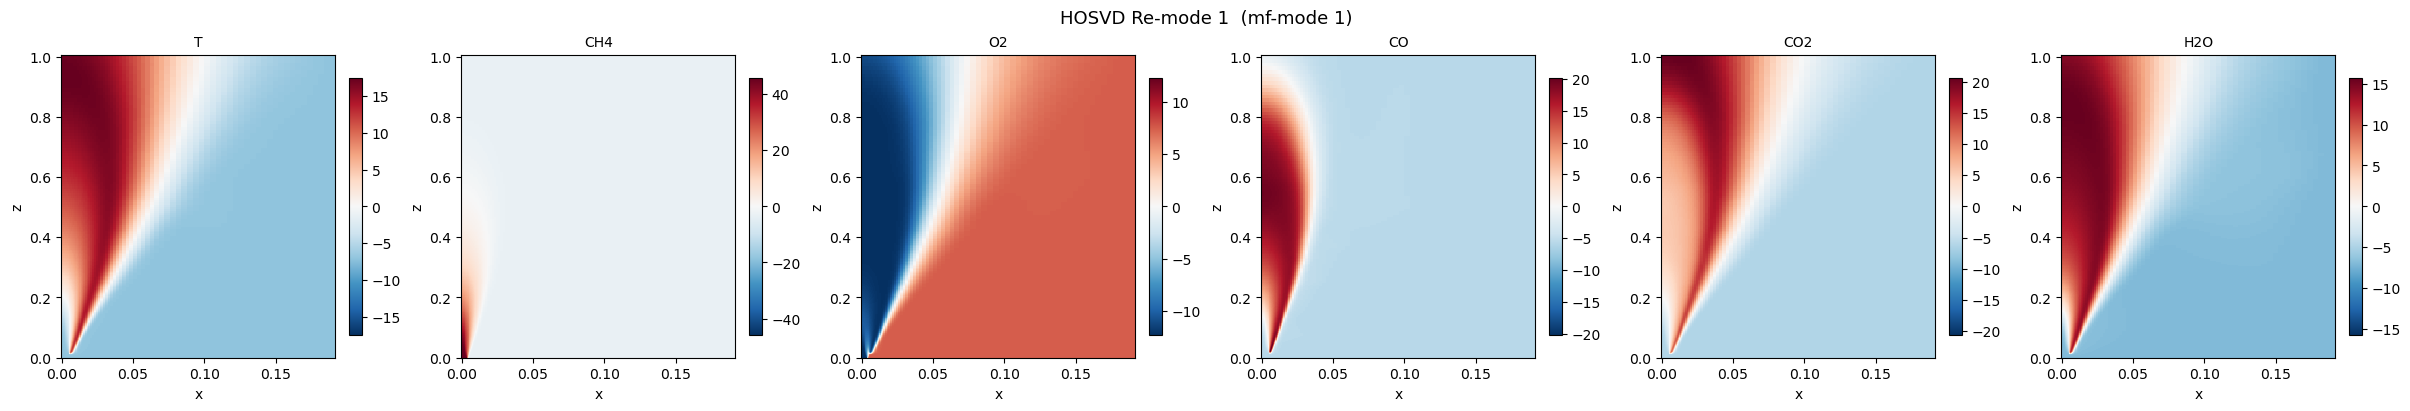

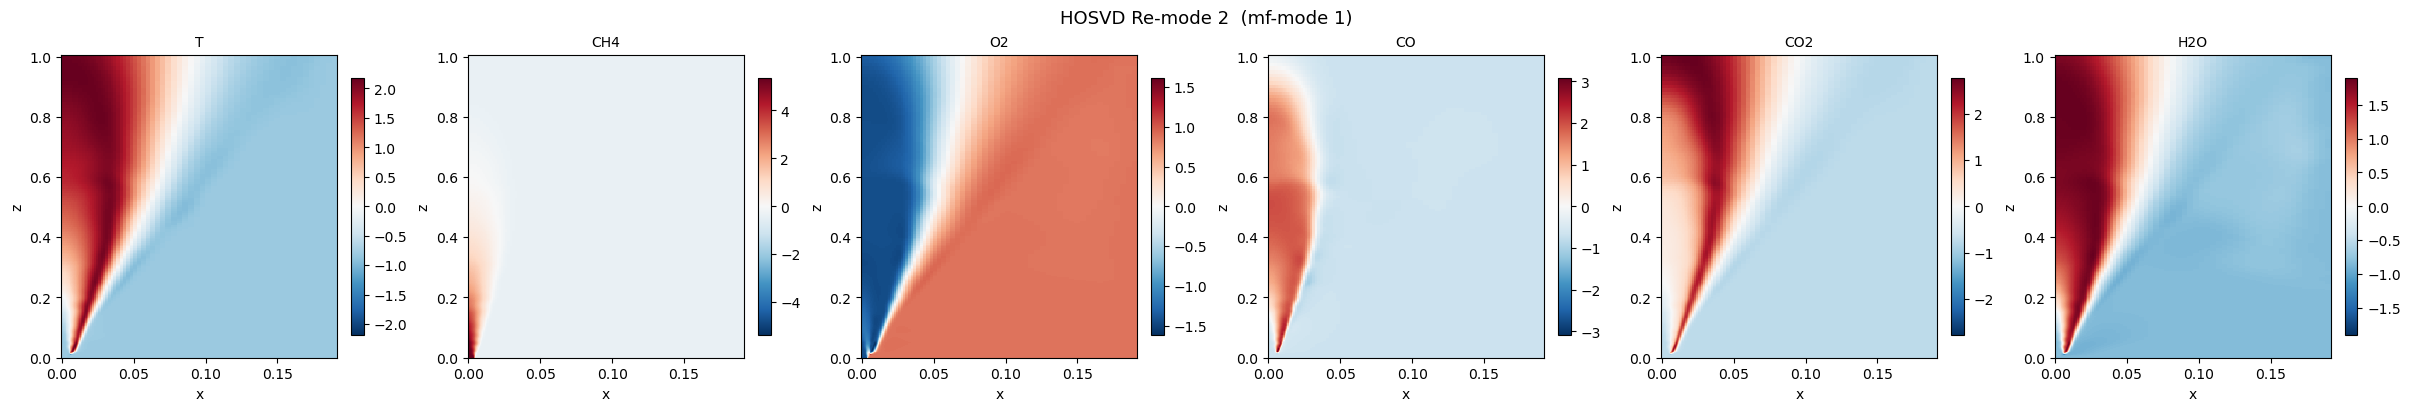

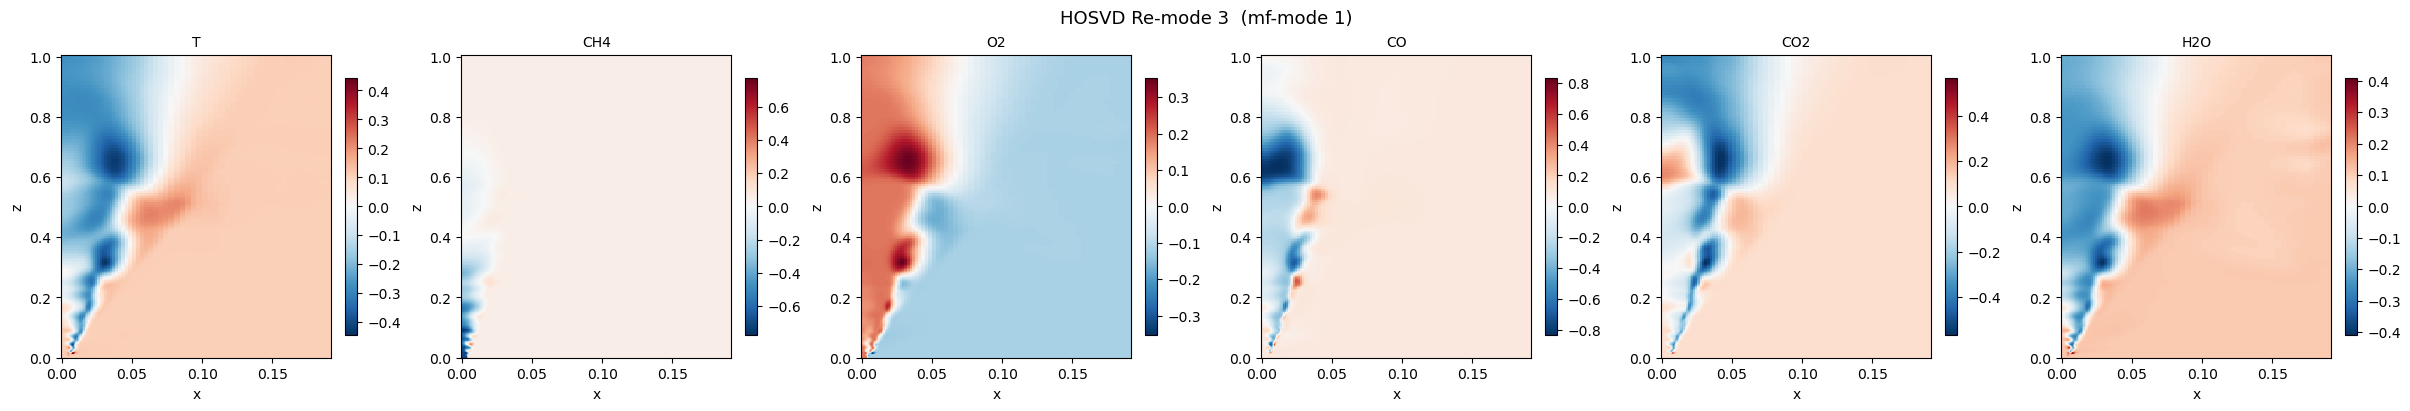

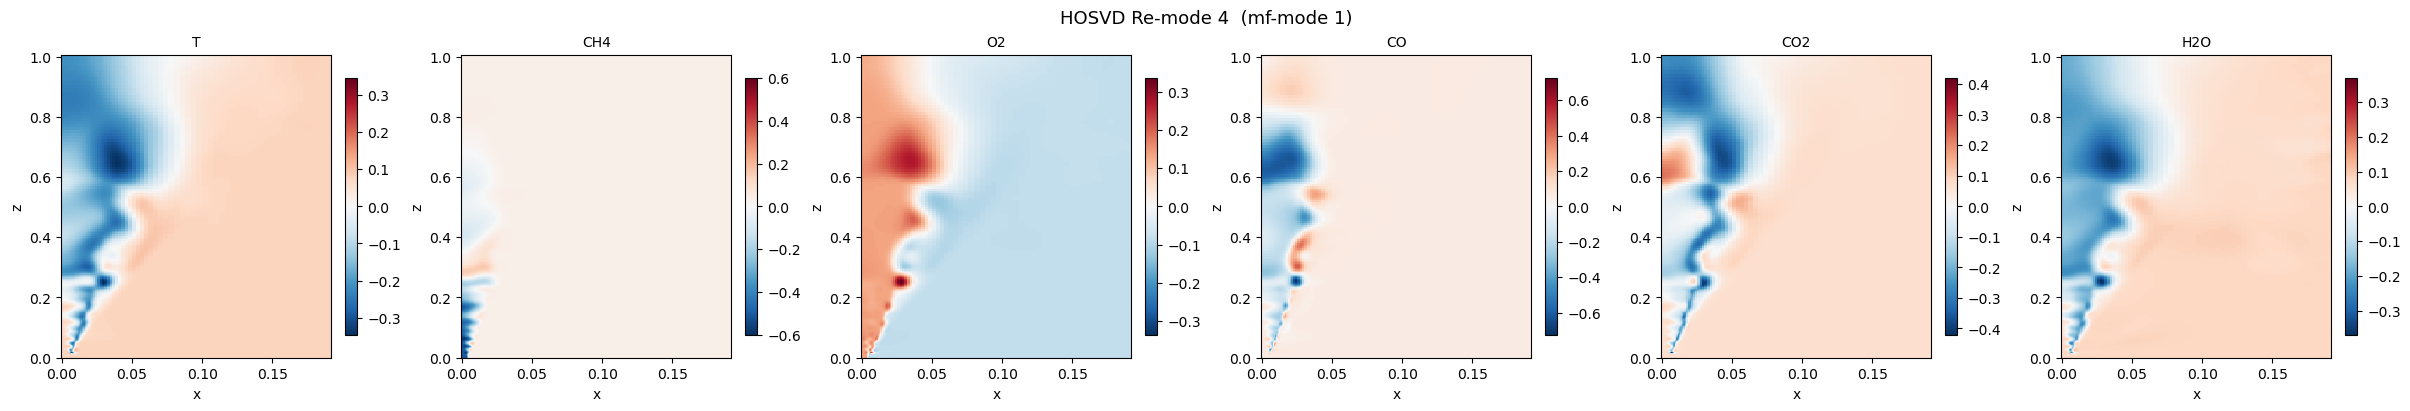

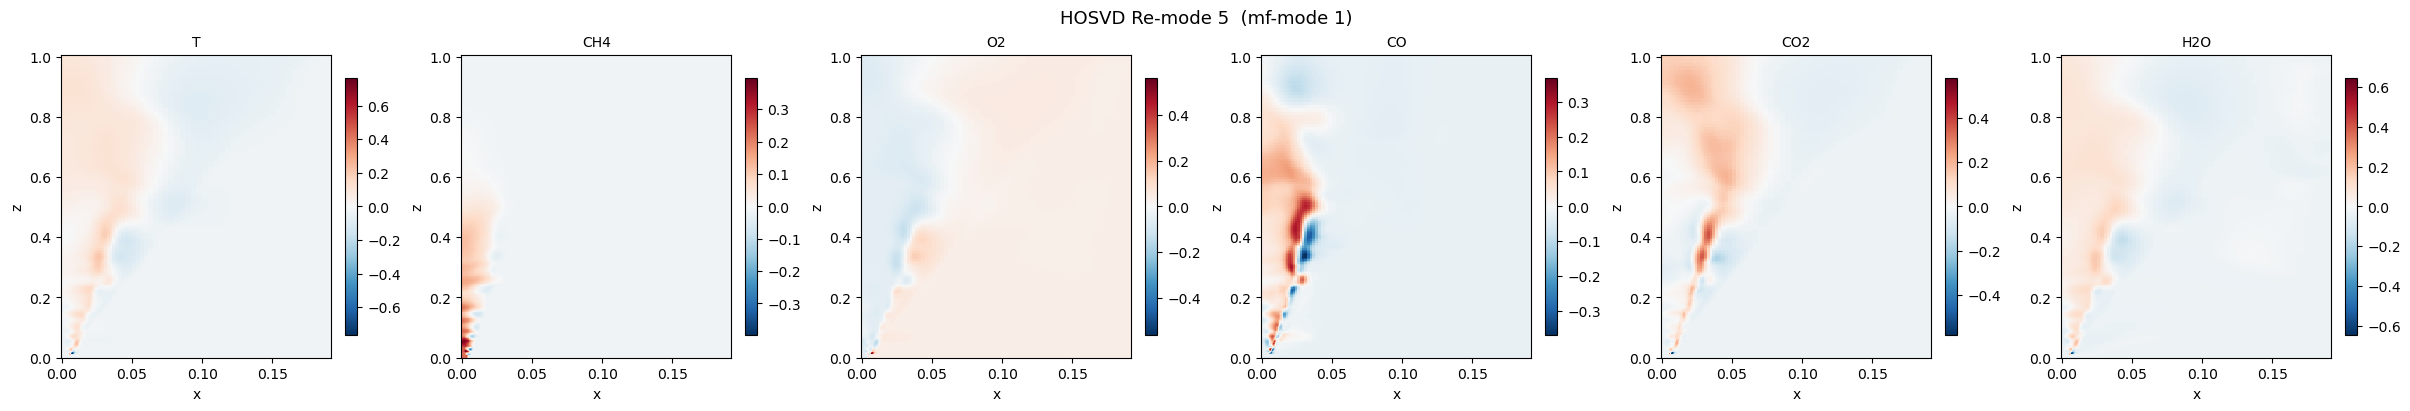

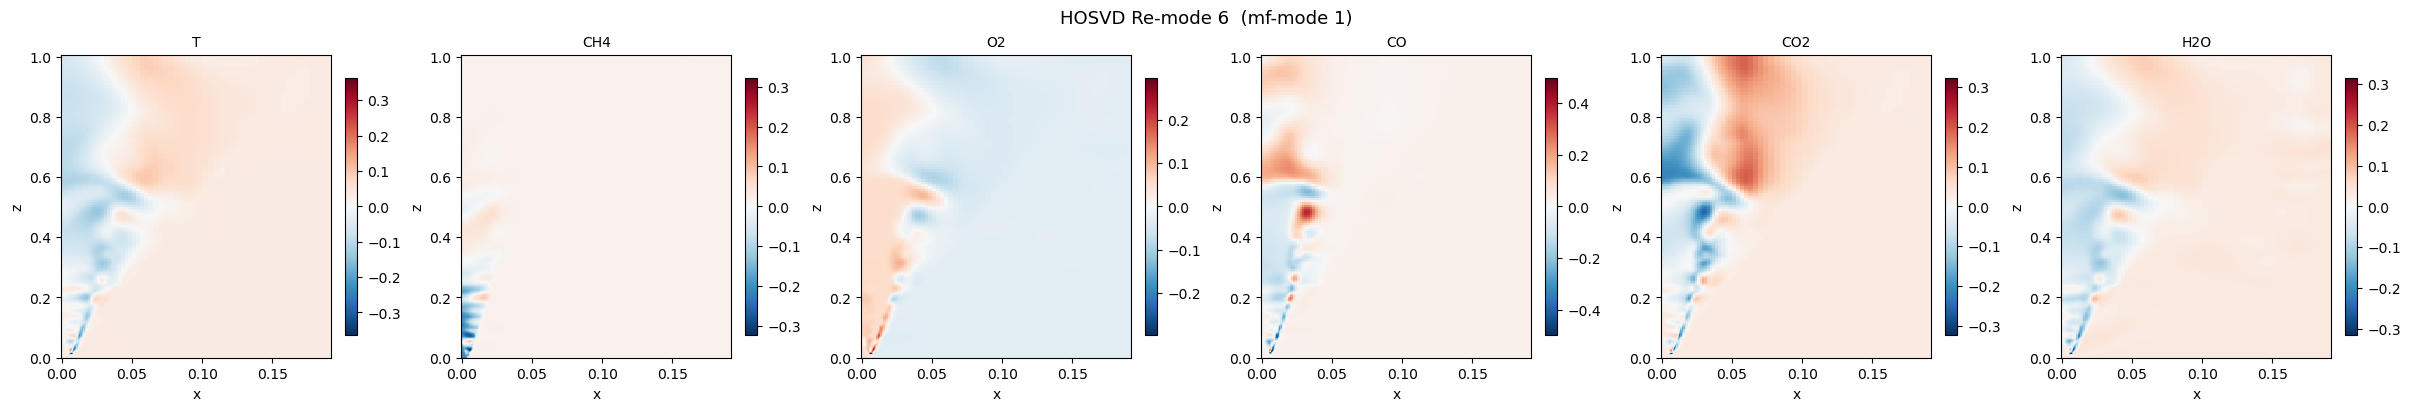

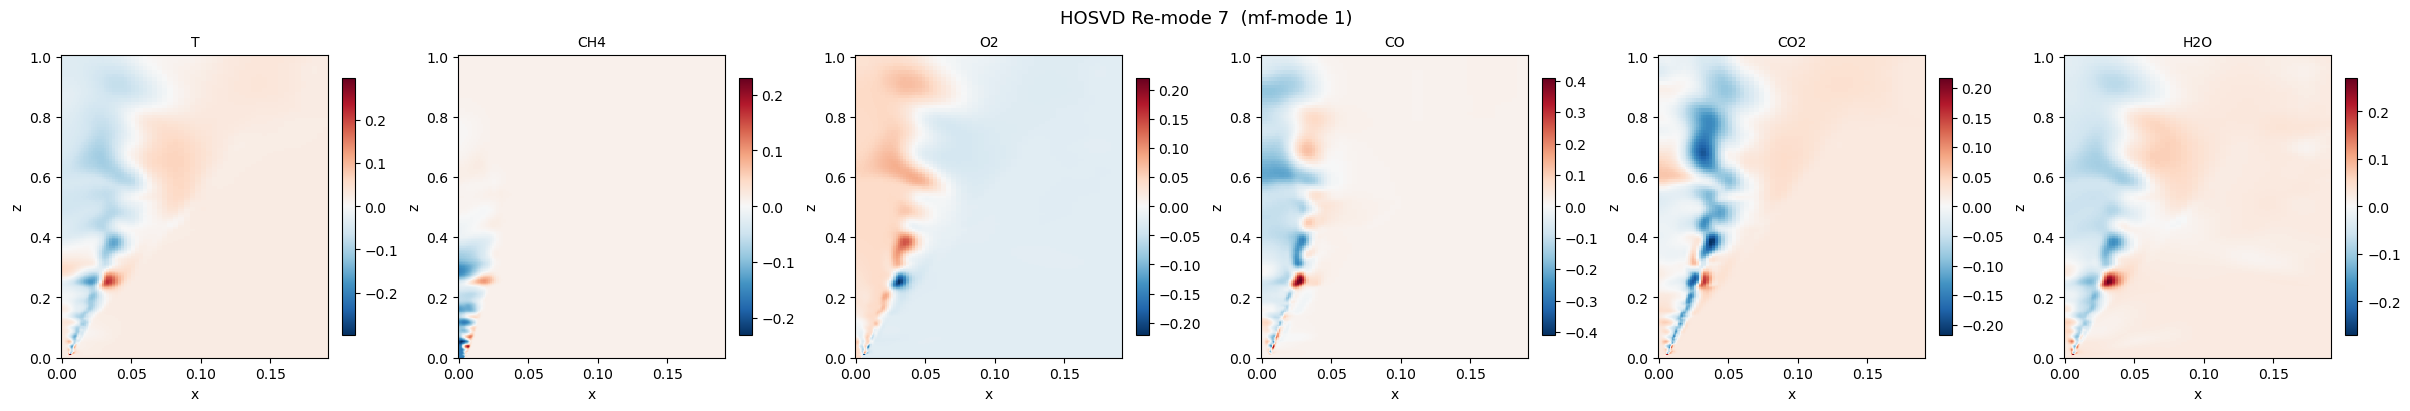

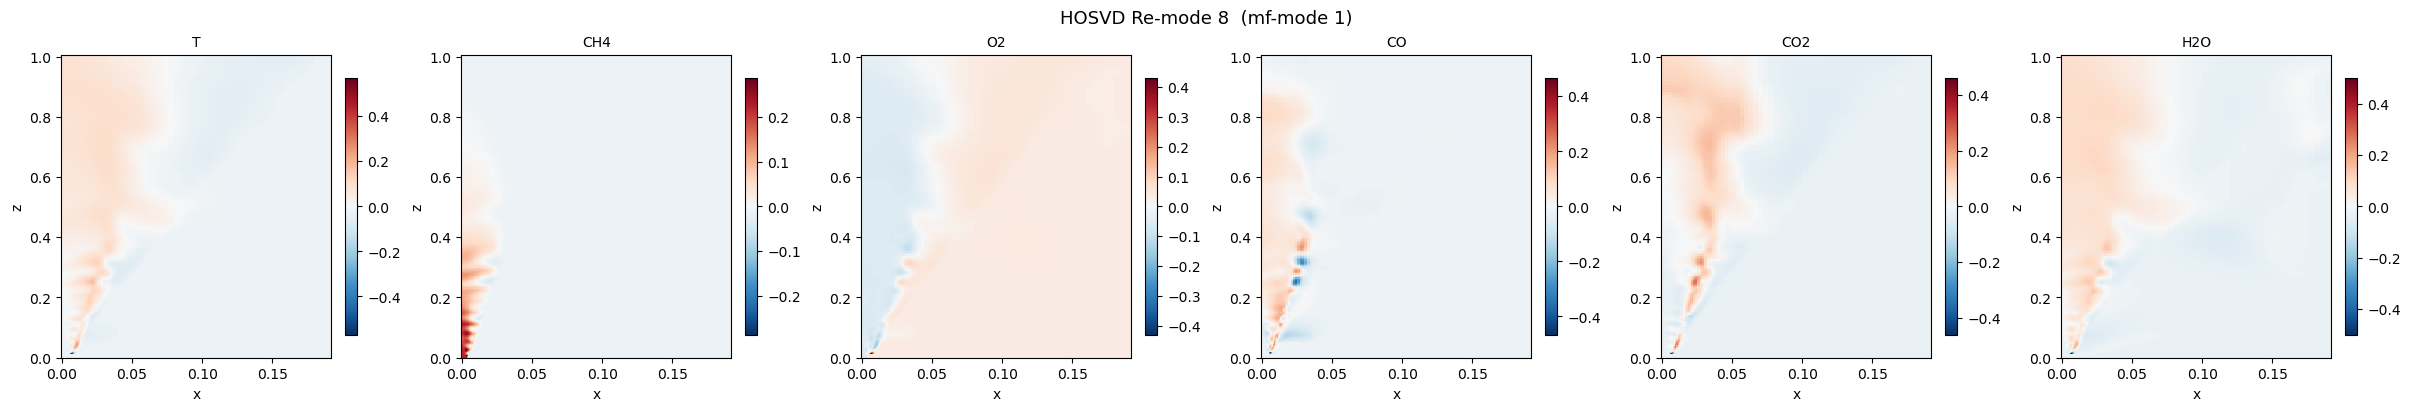

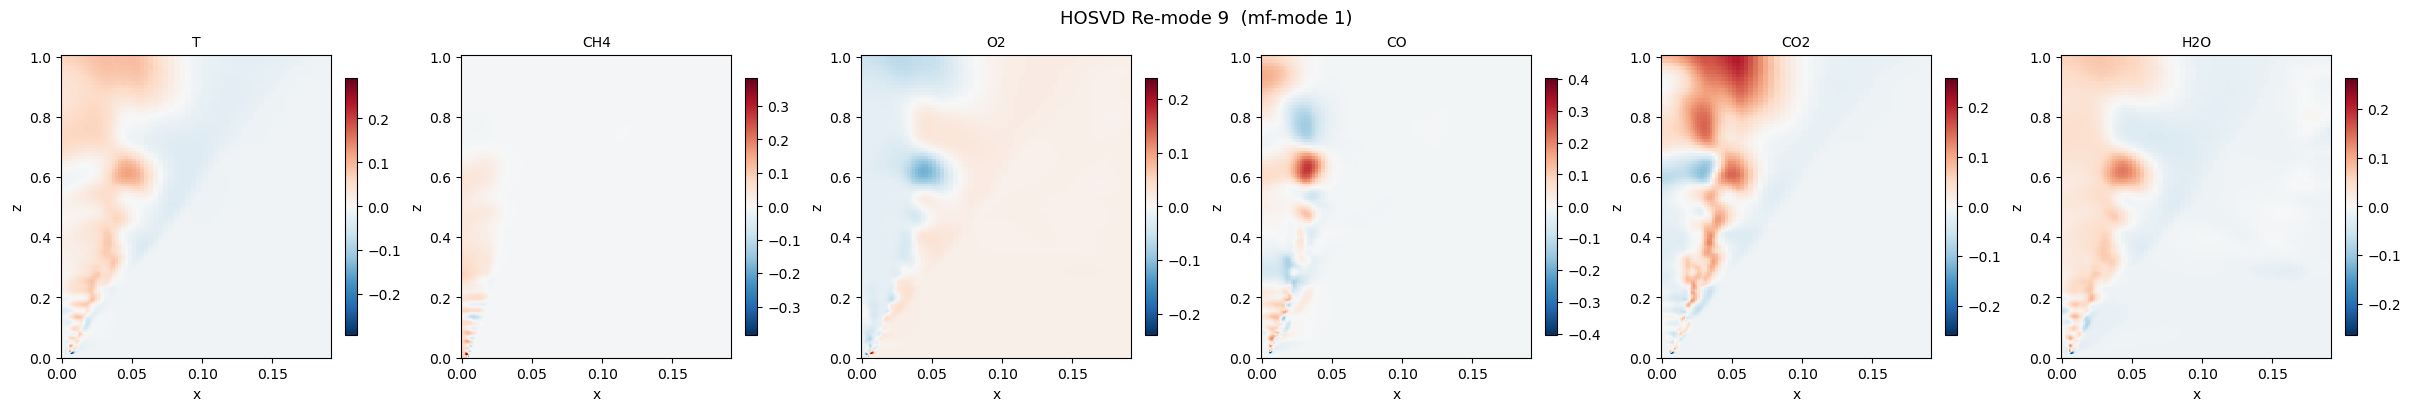

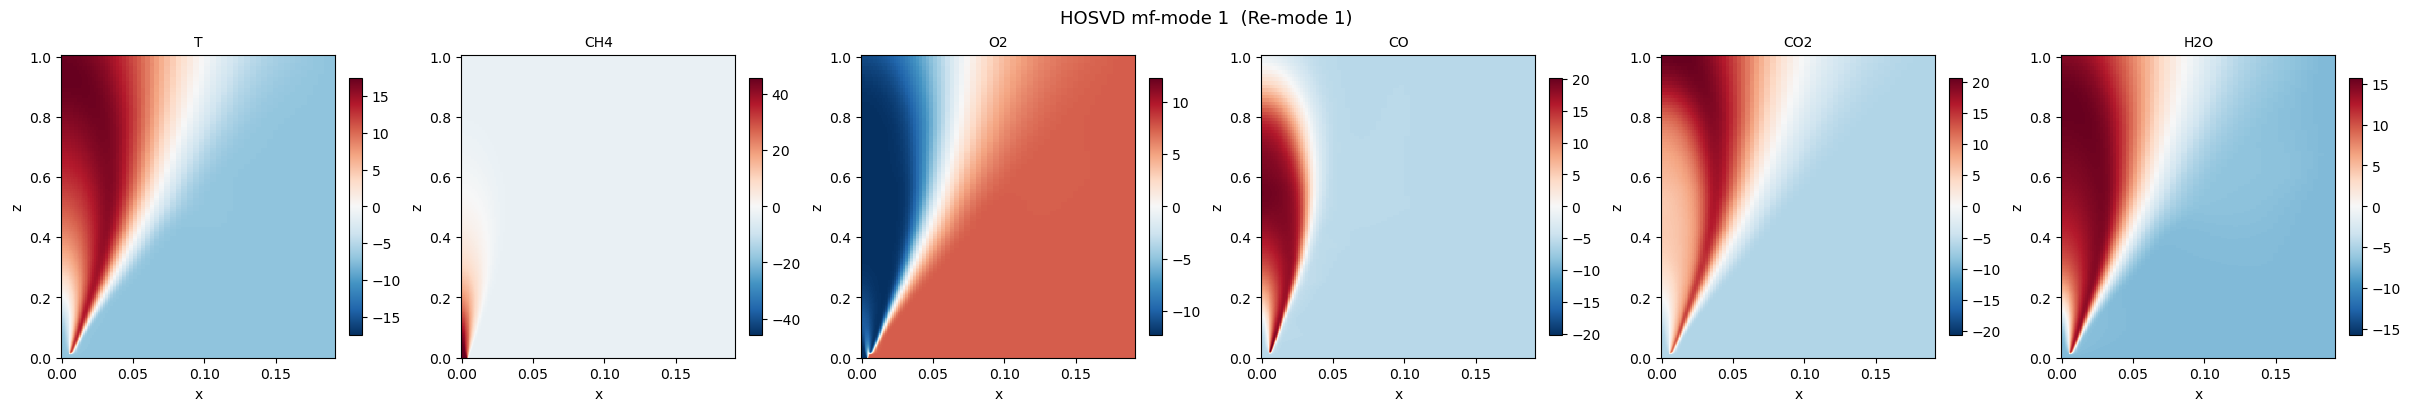

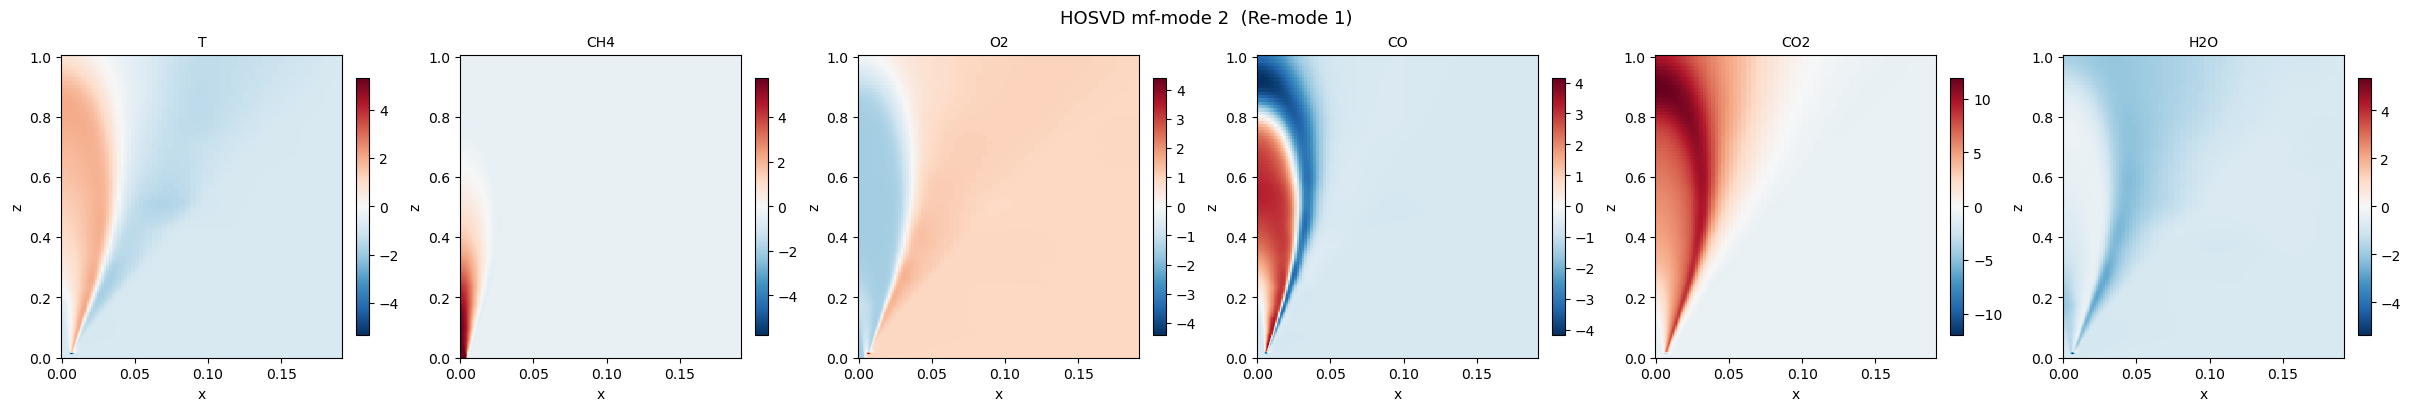

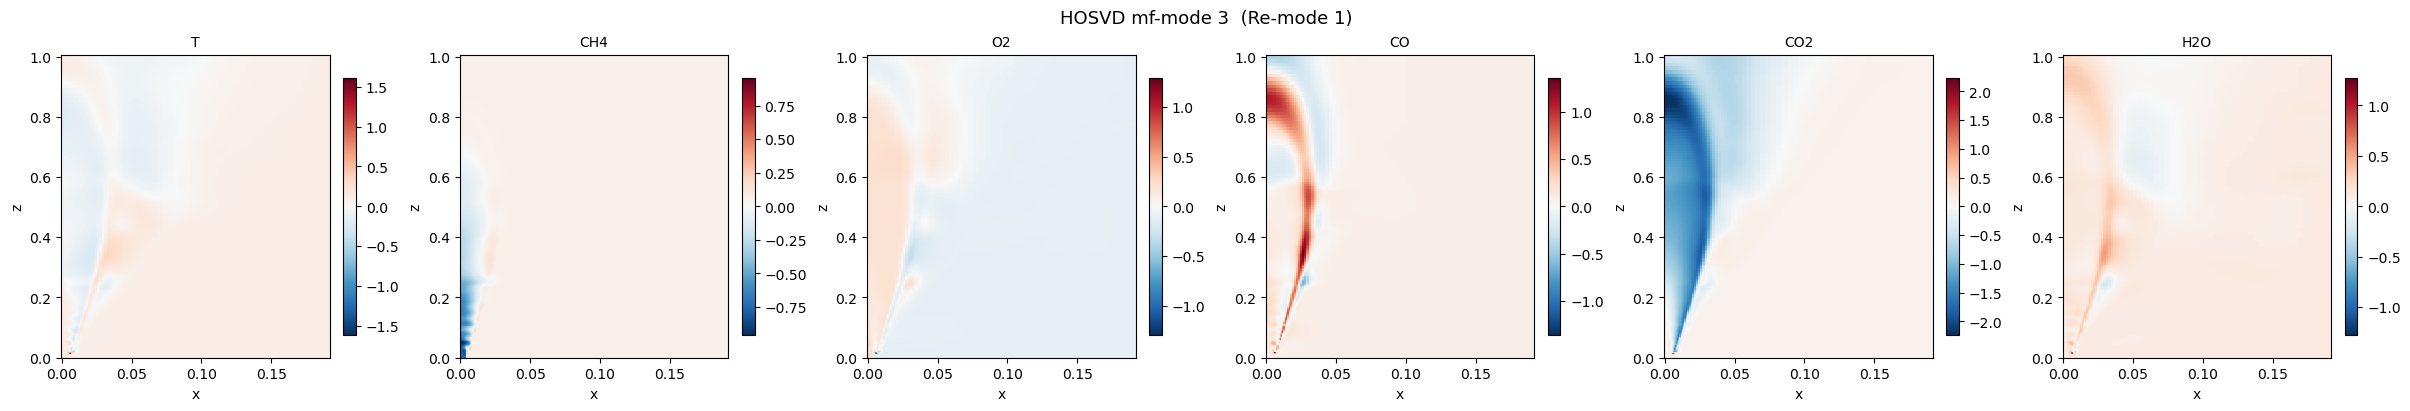

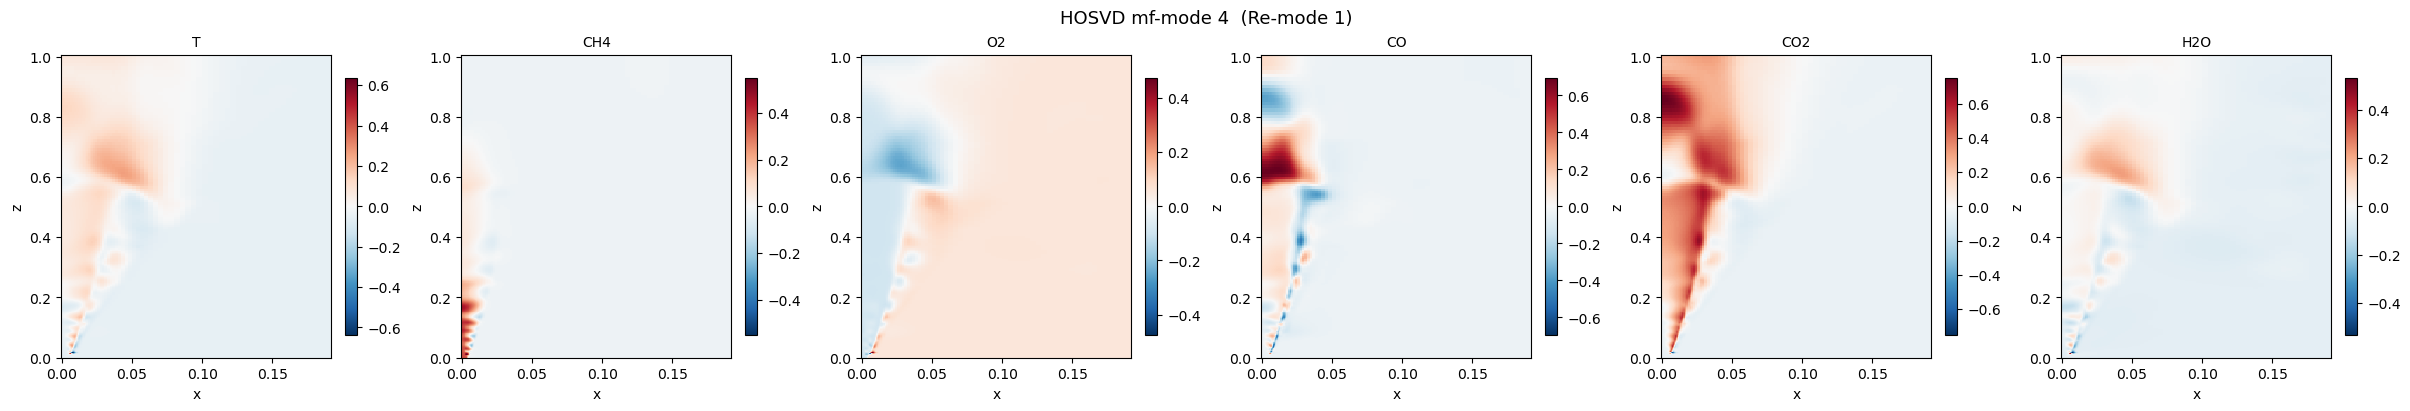

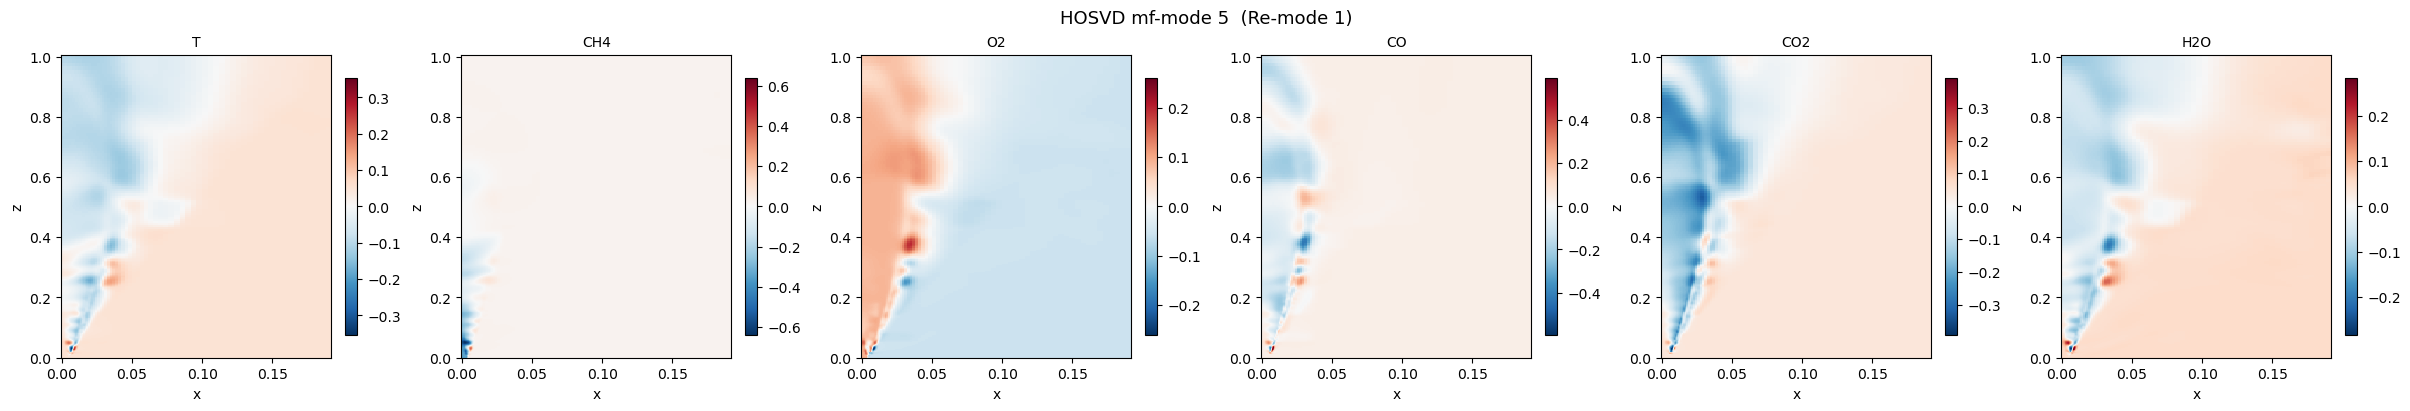

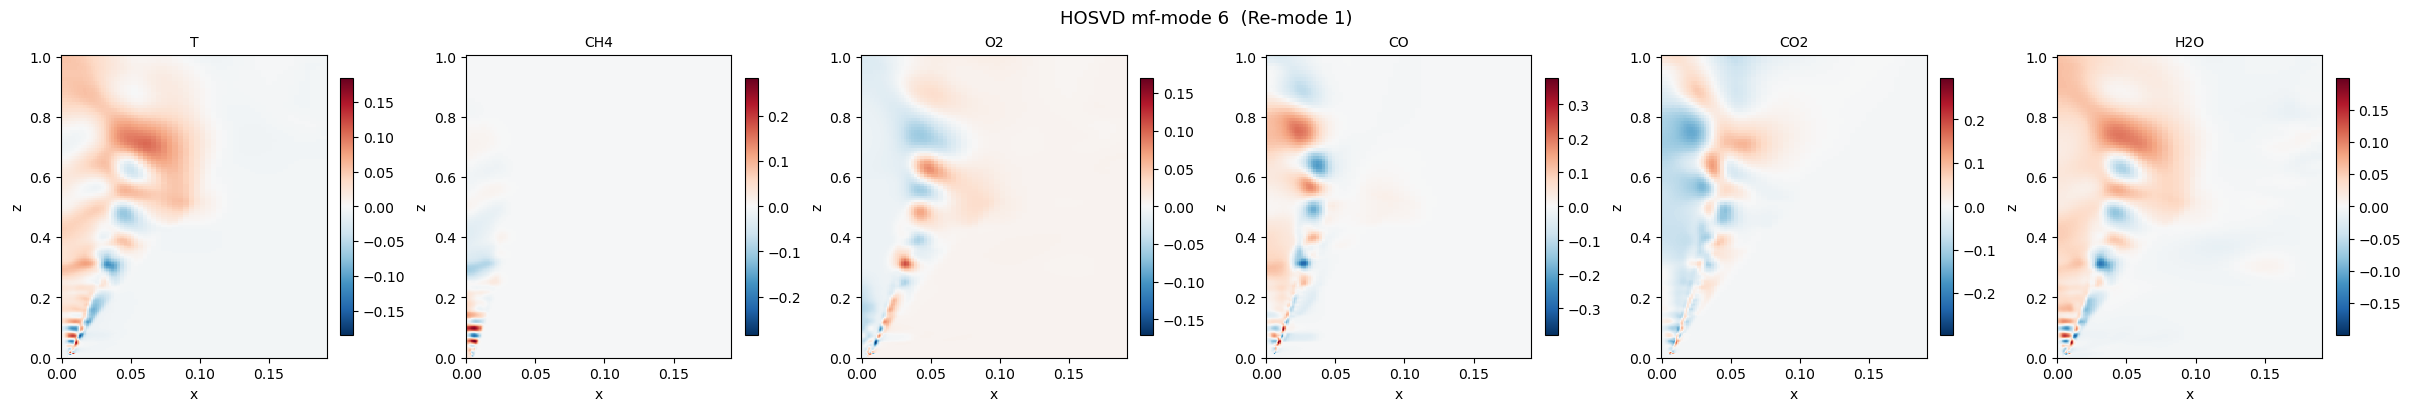

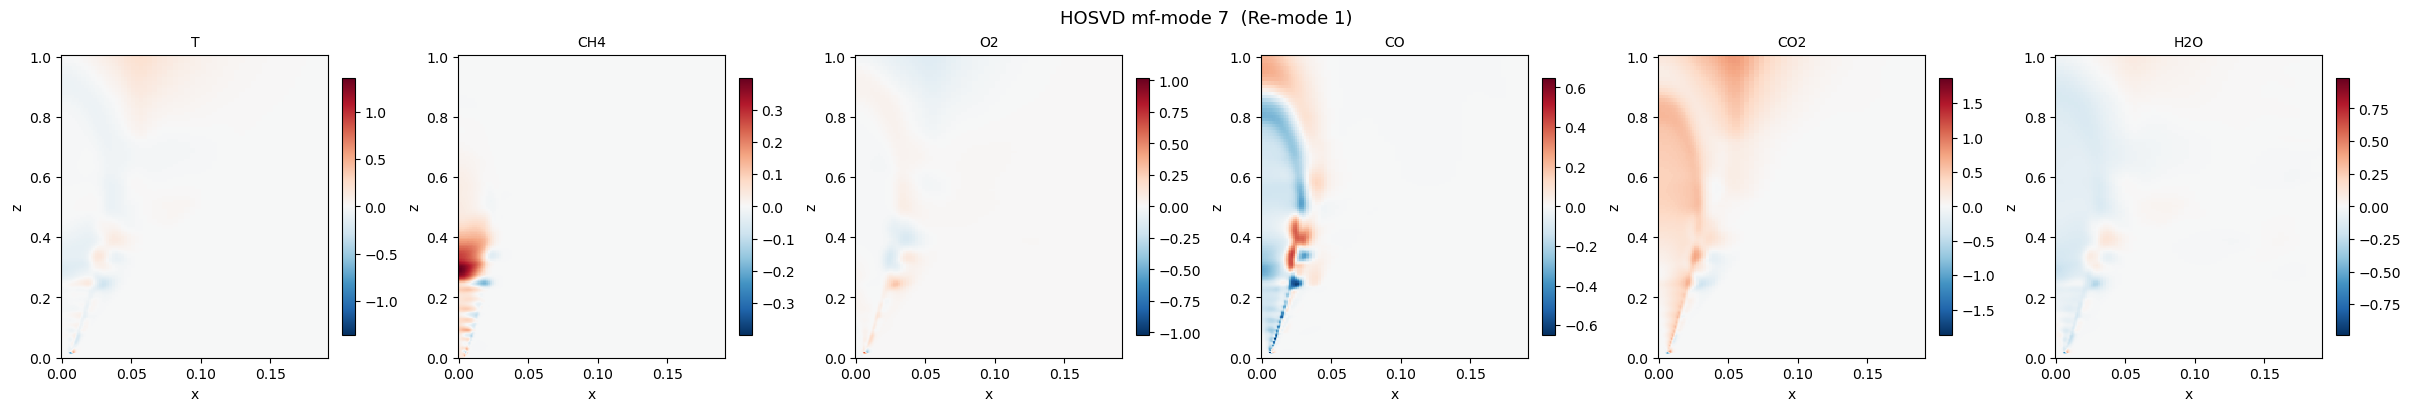

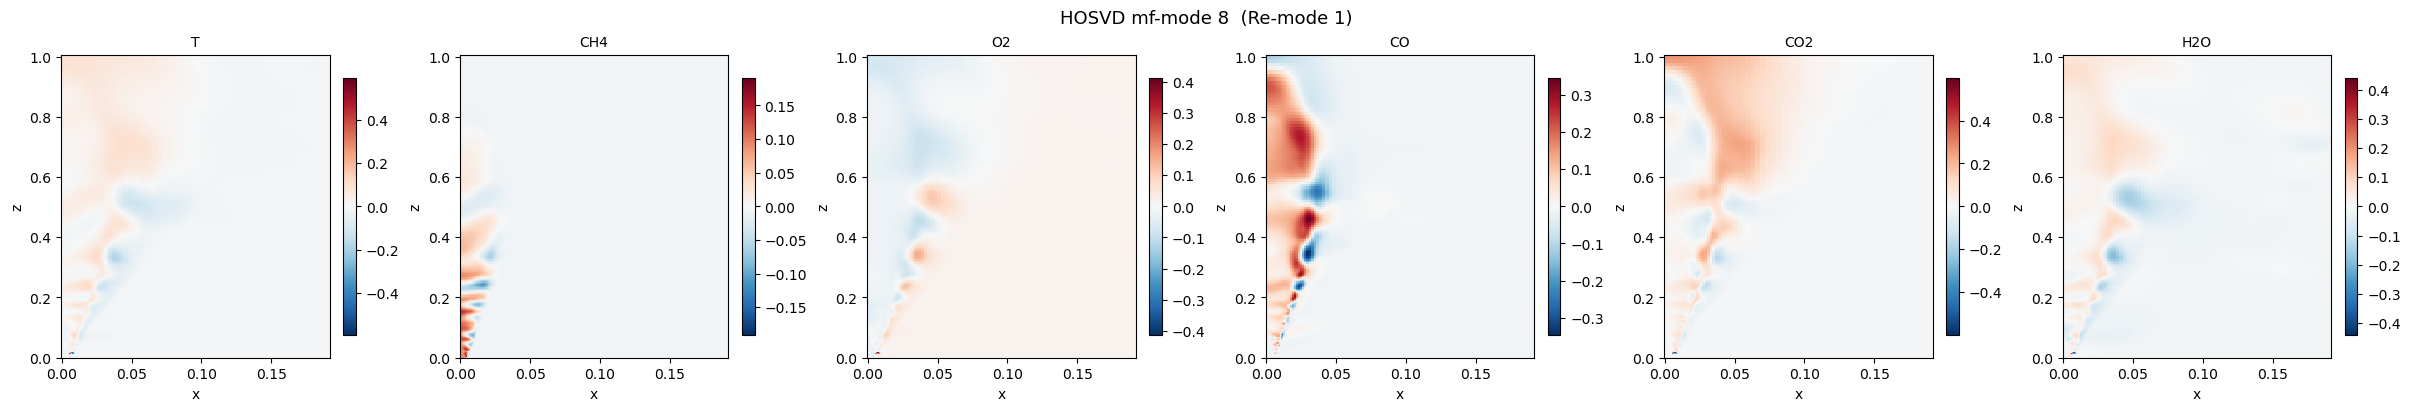

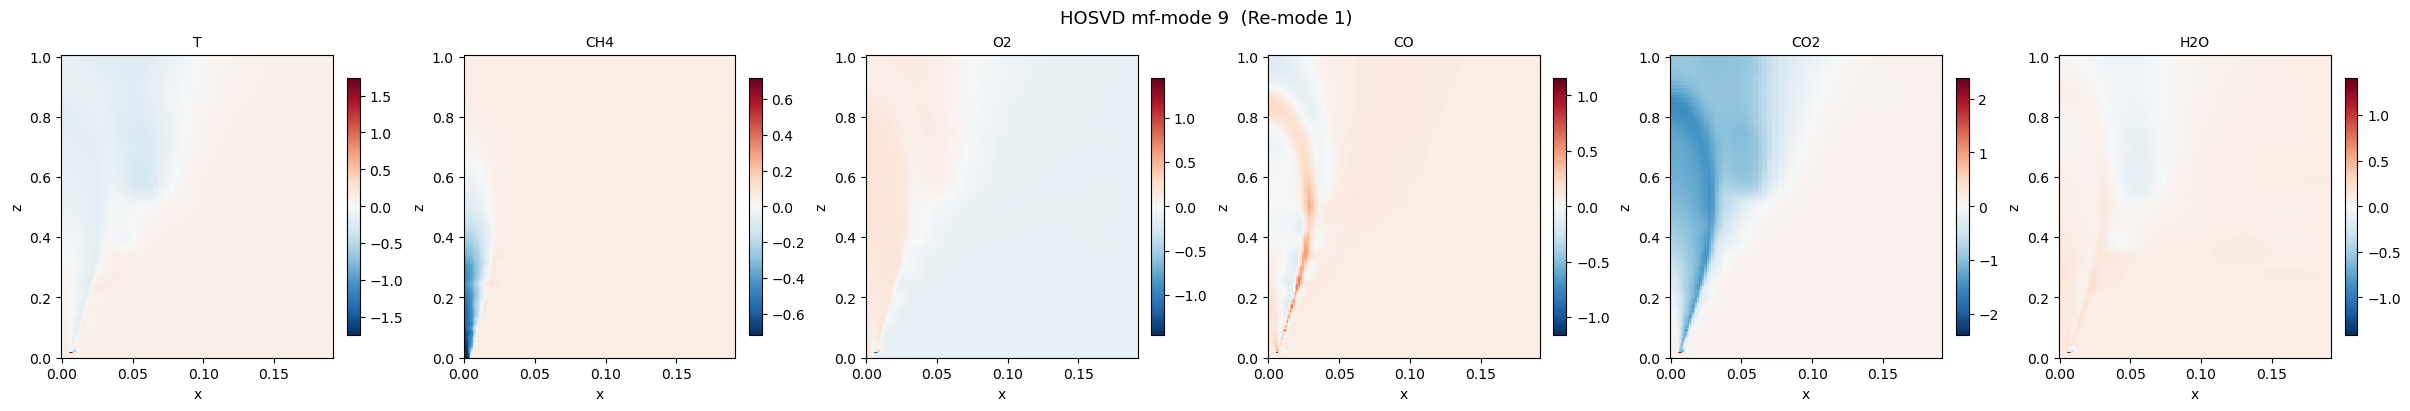

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualise HOSVD spatial modes
# ─────────────────────────────────────────────────────────────────────────────
# factors[0] : U_re  (n_re_tr, r_re)
# factors[1] : U_mf  (n_mf_tr, r_mf)
# factors[2] : U_z   (Nz, r_z)
# factors[3] : U_x   (Nx, r_x)
# factors[4] : U_sp  (Nsp, r_sp)
# core shape : (r_re, r_mf, r_z, r_x, r_sp)

U_z  = factors[2]   # (Nz,  r_z)
U_x  = factors[3]   # (Nx,  r_x)
U_sp = factors[4]   # (Nsp, r_sp)

fields_to_plot = IMPORTANT_FIELDS
n_fields       = len(fields_to_plot)

# --- Re spatial modes: fix j=0, reconstruct spatial field for each i ---
for i in range(r_re):
    # slice core at (i, 0, :, :, :) → (r_z, r_x, r_sp)
    core_slice = core[i, 0, :, :, :]

    # project back to physical space: (Nz, Nx, Nsp)
    mode_phys = tl.tenalg.multi_mode_dot(
        core_slice, [U_z, U_x, U_sp], modes=[0, 1, 2]
    )

    fig, axes = plt.subplots(1, n_fields, figsize=(4 * n_fields, 4),
                             constrained_layout=True)
    if n_fields == 1:
        axes = [axes]
    fig.suptitle(f'HOSVD Re-mode {i+1}  (mf-mode 1)', fontsize=13)

    for ax, field in zip(axes, fields_to_plot):
        sp_idx  = COL_IDX[field]
        mode_2d = mode_phys[:, :, sp_idx]         # (Nz, Nx)

        vmax = np.abs(mode_2d).max()
        im = ax.pcolormesh(x_vals, z_vals, mode_2d,
                           cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
        fig.colorbar(im, ax=ax, shrink=0.85)
        ax.set_title(field, fontsize=10)
        ax.set_xlabel('x')
        ax.set_ylabel('z')
        ax.set_aspect('auto')

    fig.savefig(PLOT_DIR / f'hosvd_re_mode_{i+1}.png', dpi=150)
    plt.show()
    plt.close(fig)

# --- mf spatial modes: fix i=0, reconstruct spatial field for each j ---
for j in range(r_mf):
    core_slice = core[0, j, :, :, :]              # (r_z, r_x, r_sp)

    mode_phys = tl.tenalg.multi_mode_dot(
        core_slice, [U_z, U_x, U_sp], modes=[0, 1, 2]
    )                                              # (Nz, Nx, Nsp)

    fig, axes = plt.subplots(1, n_fields, figsize=(4 * n_fields, 4),
                             constrained_layout=True)
    if n_fields == 1:
        axes = [axes]
    fig.suptitle(f'HOSVD mf-mode {j+1}  (Re-mode 1)', fontsize=13)

    for ax, field in zip(axes, fields_to_plot):
        sp_idx  = COL_IDX[field]
        mode_2d = mode_phys[:, :, sp_idx]         # (Nz, Nx)

        vmax = np.abs(mode_2d).max()
        im = ax.pcolormesh(x_vals, z_vals, mode_2d,
                           cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
        fig.colorbar(im, ax=ax, shrink=0.85)
        ax.set_title(field, fontsize=10)
        ax.set_xlabel('x')
        ax.set_ylabel('z')
        ax.set_aspect('auto')

    fig.savefig(PLOT_DIR / f'hosvd_mf_mode_{j+1}.png', dpi=150)
    plt.show()
    plt.close(fig)